In [2]:
import os
import numpy as np
import pandas as pd
import plotnine as pln

In [4]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

# Viral x Non-viral proteins

In [3]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/nonviral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/nonviral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

In [4]:
cols = ['Fold', 'R2_score_train', 'MAE_score_train', 'RMSE_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_train',
       'rho_score_test', 'dataset', 'Model', 'Source']

In [5]:
res_full = pd.DataFrame()
for method in ['lassoCV', 'lassoCV_SS']:
  
    res_dir_path = f'../experiments/{method}/esmc_300m/viral'
    res_esmc_viral = read_results(res_dir_path, 'esmc_300m')
    res_esmc_viral['Source'] = 'Viral'

    res_dir_path = f'../experiments/{method}/esmc_300m/nonviral'
    res_esmc_nonviral = read_results(res_dir_path, 'esmc_300m')
    res_esmc_nonviral['Source'] = 'Non-viral'

    res = pd.concat([res_esmc_viral[cols], res_esmc_nonviral[cols]], ignore_index=True)
    
    if method == 'lassoCV':
        res['split_method'] = 'Random'
    elif method == 'lassoCV_SS':
        res['split_method'] = 'Site Split'
    res_full = pd.concat([res_full, res], ignore_index=True)


res_full['prot_length'] = res_full['dataset'].map(prot_lengths)
res_full

,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,dataset,Model,Source,split_method,prot_length
0,1,0.152806,0.979265,1.153412,0.149275,1.014056,1.190759,0.449031,0.443836,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
1,2,0.169021,0.970161,1.149612,0.145919,0.979100,1.164417,0.463298,0.406275,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
2,3,0.155750,0.978670,1.157638,0.144804,1.002378,1.169608,0.442005,0.427625,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
3,4,0.159683,0.983598,1.159307,0.151166,0.971936,1.147394,0.454222,0.434357,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
4,5,0.168392,0.977333,1.154080,0.160534,0.960227,1.137875,0.457064,0.464171,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,1,0.288483,0.352836,0.430025,-0.017784,0.397757,0.545227,0.561937,0.556324,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439
736,2,0.327380,0.346957,0.423799,0.235062,0.376635,0.450349,0.595883,0.497144,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439
737,3,0.330599,0.343594,0.421779,-0.240680,0.435247,0.578614,0.597497,0.491398,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439
738,4,0.329413,0.350373,0.427955,0.173409,0.347891,0.445133,0.594941,0.511561,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439


In [6]:
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train', 'prot_length']
res_full = res_full.groupby(['dataset', 'split_method', 'Source'], as_index=False)[cols].mean()
res_full 

,dataset,split_method,Source,rho_score_test,R2_score_test,rho_score_train,R2_score_train,prot_length
0,AMIE_PSEAE_Whitehead,Random,Non-viral,0.555898,0.299995,0.575970,0.319214,346.0
1,AMIE_PSEAE_Whitehead,Site Split,Non-viral,0.472744,0.123492,0.588454,0.329509,346.0
2,B3VI55_LIPSTSTABLE,Random,Non-viral,0.564621,0.288673,0.575836,0.300510,439.0
3,B3VI55_LIPSTSTABLE,Site Split,Non-viral,0.515237,0.066101,0.584234,0.312678,439.0
4,B3VI55_LIPST_Whitehead2015,Random,Non-viral,0.381656,0.132217,0.395756,0.142379,439.0
...,...,...,...,...,...,...,...,...
143,UBC9_HUMAN_Roth2017,Site Split,Non-viral,0.535970,-0.203271,0.786375,0.553758,159.0
144,UBE4B_MOUSE_Klevit2013_singles,Random,Non-viral,0.498197,0.296340,0.630457,0.447334,1173.0
145,UBE4B_MOUSE_Klevit2013_singles,Site Split,Non-viral,0.392854,0.011835,0.604901,0.412279,1173.0
146,YAP1_HUMAN_Fields2012_singles,Random,Non-viral,0.722226,0.470280,0.841138,0.671917,504.0


In [7]:
res_full.groupby(['split_method', 'Source'], as_index=False)[cols].mean()

,split_method,Source,rho_score_test,R2_score_test,rho_score_train,R2_score_train,prot_length
0,Random,Non-viral,0.626153,0.430427,0.665728,0.485910,449.000000
1,Random,Viral,0.360529,0.152124,0.387388,0.172085,590.731707
2,Site Split,Non-viral,0.553452,0.197418,0.666305,0.487057,449.000000
3,Site Split,Viral,0.270419,-0.010132,0.387381,0.176188,590.731707


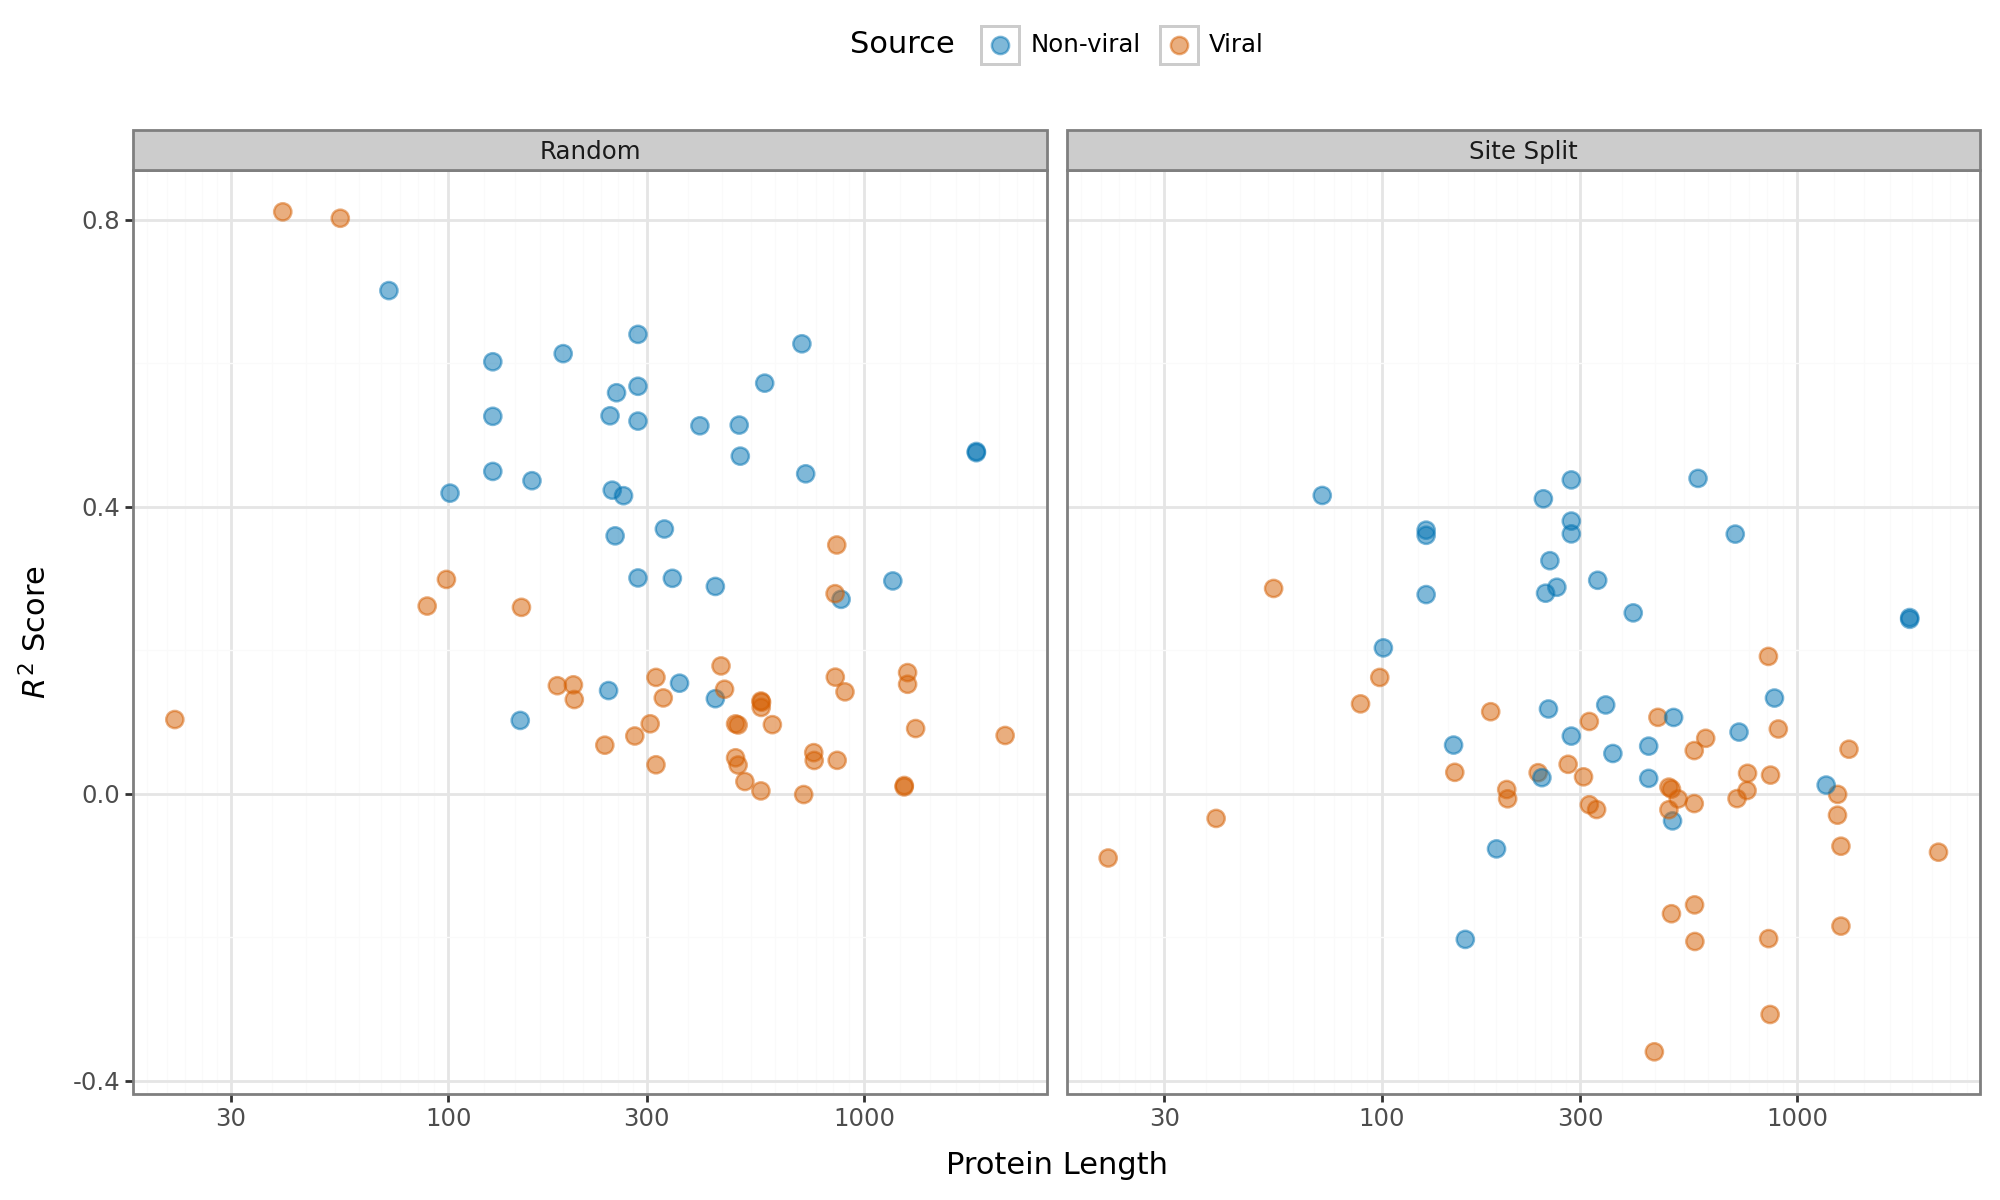

In [8]:
plot = (
    pln.ggplot(res_full, pln.aes(x='prot_length', y='R2_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"Viral": "#D55E00", "Non-viral": "#0072B2"})
    + pln.facet_wrap('split_method')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',)
    #+ pln.ylim(-0.2, 0.8)

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

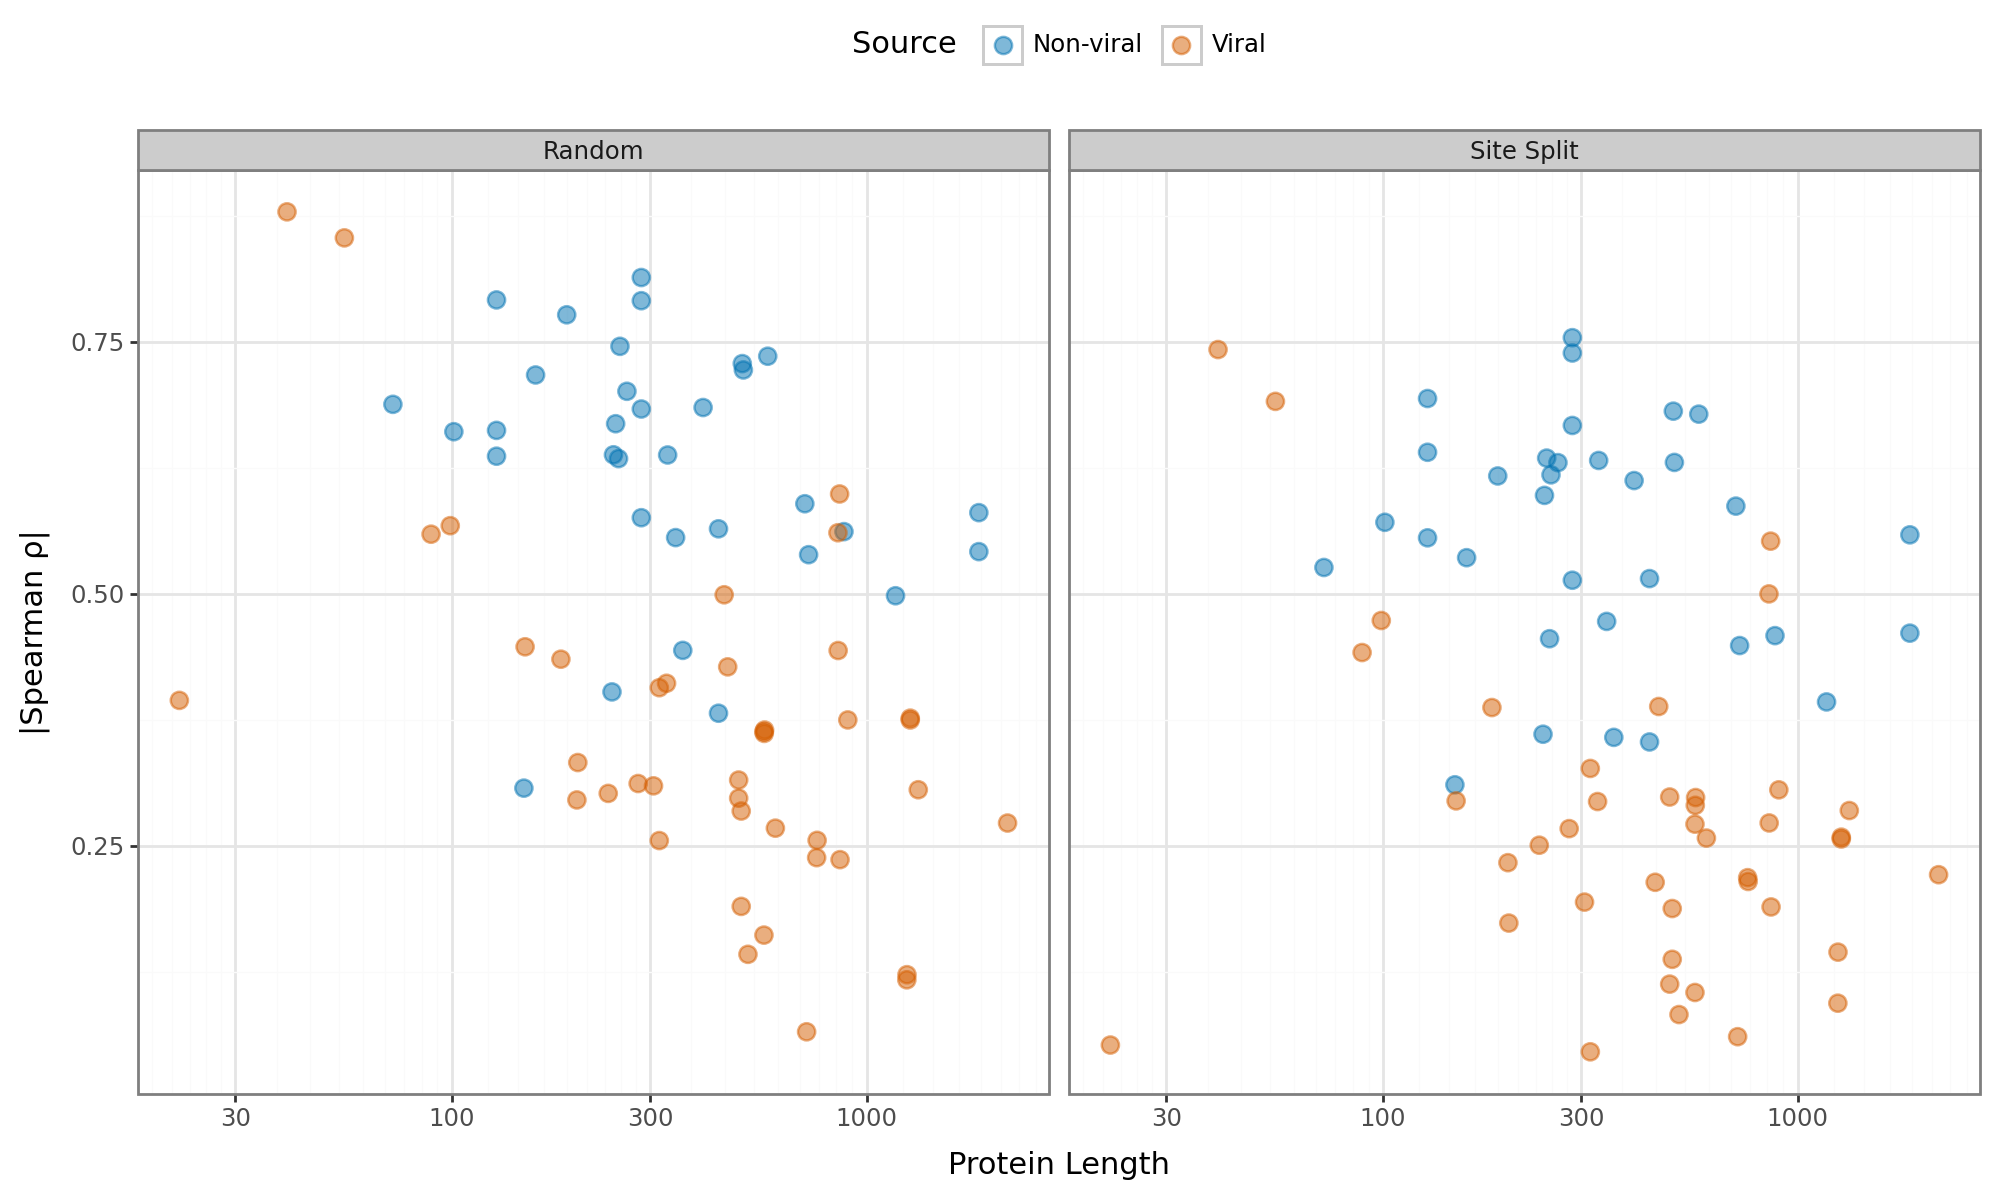

In [9]:
plot = (
    pln.ggplot(res_full, pln.aes(x='prot_length', y='rho_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"Viral": "#D55E00", "Non-viral": "#0072B2"})
    + pln.facet_wrap('split_method')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y='|Spearman ρ|')
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',)

)
plot#.save(filename='../experiments/protein_length_vs_rho.png', dpi=600)

In [10]:
res_pivot = res_full.pivot_table(index=['dataset', 'Source'], columns='split_method', values='R2_score_test').reset_index()
res_pivot.to_csv('../experiments/viral_nonviral_splits_lassoCV_results.csv')

In [11]:
stop

NameError: name 'stop' is not defined

In [ ]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='Random', x='Site Split'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.geom_abline(slope=1, intercept=0, linetype='dashed', color='grey')
    + pln.scale_color_manual(values={"Viral": "#D55E00", "Non-viral": "#0072B2"})
    + pln.labs(y="Random", x="Site Split")
    + pln.theme_bw()
    + pln.theme(figure_size=(8, 6), legend_position='top',)
    + pln.ylim(-0.45, 1)
    + pln.xlim(-0.45, 1)

)
plot#.save(filename='../experiments/random_x_SS_lassocv_r2_full.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../experiments/random_x_SS_lassocv_r2_full.png


## non-viral x viral 

In [ ]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Source', y='R2_score_test'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.labs(
        x='Source',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(10, 5.5),
        panel_grid_major_x=pln.element_blank(),
    )
    + pln.facet_wrap('split_method', ncol=2)
)

plot.save(filename='../experiments/sup1_lassocv_source_splits_r2_full.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5.5 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../experiments/lassocv_source_splits_r2_full.png


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 9 rows containing non-finite values.


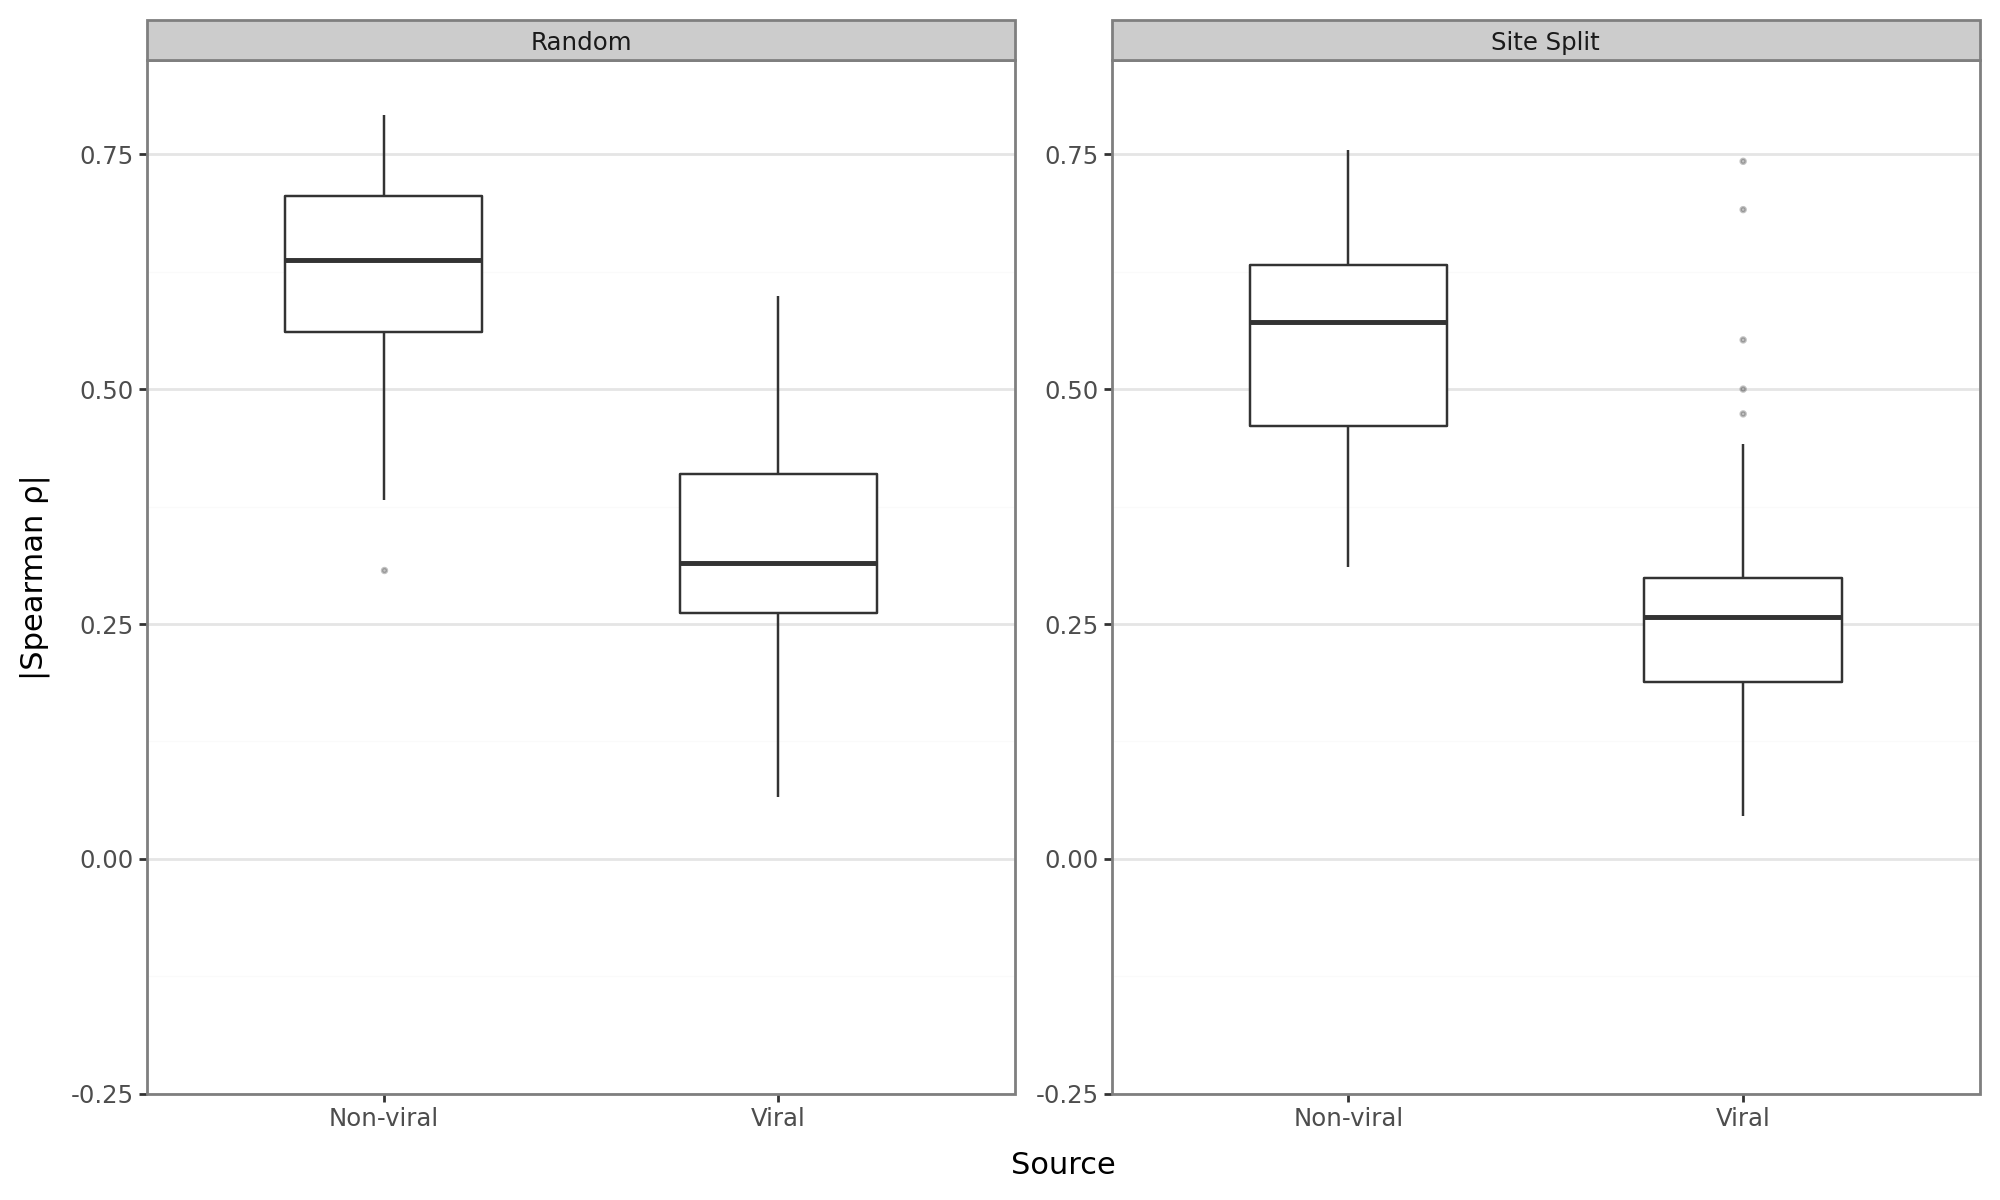

In [ ]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Source', y='rho_score_test'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.labs(
        x='Source',
        y='|Spearman ρ|',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(10, 6),
        panel_grid_major_x=pln.element_blank(),
    )
    + pln.facet_wrap('split_method', ncol=2, scales='free_y')
)

plot#.save(filename='../experiments/lassocv_source_splits_rho.png', dpi=600)

# Fine tuned models

In [8]:
res_full = pd.DataFrame()
for method in ['lassoCV', 'lassoCV_SS']:
  
    res_dir_path = f'../experiments/{method}/esmc_300m/viral'
    res_esmc = read_results(res_dir_path, 'esmc_300m')

    res_dir_path = f'../experiments/{method}/rsawhney_esm2_3B/viral'
    res_rsawhney = read_results(res_dir_path, 'rsawhney_esm2_3B')

    res_dir_path = f'../experiments/{method}/vicam_300m/viral/CRVDBv29_maxLen1022_Full_lr5e4_RLRP'
    ViCam_300m_full = read_results(res_dir_path, 'ViCam_300m')

    res = pd.concat([res_esmc, res_rsawhney, ViCam_300m_full,], ignore_index=True)
    #res = pd.concat([res_esmc, ViCam_300m_full], ignore_index=True)
    if method == 'lassoCV':
        res['split_method'] = 'Random'
    elif method == 'lassoCV_SS':
        res['split_method'] = 'Site Split'
    res_full = pd.concat([res_full, res], ignore_index=True)

res_full

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,nun_zero_coefs,Compression_method,dataset,split_method,num_zero_coefs
0,esmc_300m,1,0.152806,0.979265,1.153412,0.149275,1.014056,1.190759,0.449031,0.443836,27.0,embeddings,CVB3_3C_Alvarez,Random,NaN
1,esmc_300m,2,0.169021,0.970161,1.149612,0.145919,0.979100,1.164417,0.463298,0.406275,25.0,embeddings,CVB3_3C_Alvarez,Random,NaN
2,esmc_300m,3,0.155750,0.978670,1.157638,0.144804,1.002378,1.169608,0.442005,0.427625,24.0,embeddings,CVB3_3C_Alvarez,Random,NaN
3,esmc_300m,4,0.159683,0.983598,1.159307,0.151166,0.971936,1.147394,0.454222,0.434357,25.0,embeddings,CVB3_3C_Alvarez,Random,NaN
4,esmc_300m,5,0.168392,0.977333,1.154080,0.160534,0.960227,1.137875,0.457064,0.464171,31.0,embeddings,CVB3_3C_Alvarez,Random,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,ViCam_300m,1,0.467686,0.720448,0.992792,0.142578,1.032245,1.444152,0.679645,0.442644,NaN,NaN,SARS2_RBD_binding_Starr,Site Split,131.0
1221,ViCam_300m,2,0.456444,0.786214,1.054609,-0.145518,1.008952,1.421849,0.655534,0.321521,NaN,NaN,SARS2_RBD_binding_Starr,Site Split,108.0
1222,ViCam_300m,3,0.445173,0.777702,1.055143,0.007221,1.197821,1.380431,0.645432,0.493438,NaN,NaN,SARS2_RBD_binding_Starr,Site Split,103.0
1223,ViCam_300m,4,0.374516,0.837149,1.119671,0.029845,0.932833,1.364159,0.627797,0.453136,NaN,NaN,SARS2_RBD_binding_Starr,Site Split,92.0


In [9]:
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train']
res_full = res_full.groupby(['dataset', 'Model', 'split_method', ], as_index=False)[cols].mean()
res_full 

,dataset,Model,split_method,rho_score_test,R2_score_test,rho_score_train,R2_score_train
0,BP434_RPC1_Tsuboyama,rsawhney_esm2_3B,Random,0.637963,0.421622,0.652720,0.445067
1,BPP22_COAT_Tsuboyama,ViCam_300m,Random,0.809845,0.726529,0.892065,0.849491
2,BPP22_COAT_Tsuboyama,ViCam_300m,Site Split,0.606787,0.069543,0.886681,0.840822
3,BPP22_COAT_Tsuboyama,esmc_300m,Random,0.879123,0.810779,0.920076,0.886917
4,BPP22_COAT_Tsuboyama,esmc_300m,Site Split,0.742481,-0.034662,0.927384,0.896030
...,...,...,...,...,...,...,...
240,SARS2_XBB15_RBD_Taylor,ViCam_300m,Site Split,0.460269,0.119675,0.547530,0.307936
241,SARS2_XBB15_RBD_Taylor,esmc_300m,Random,0.332711,0.131054,0.366784,0.155581
242,SARS2_XBB15_RBD_Taylor,esmc_300m,Site Split,0.173432,-0.007322,0.342295,0.125957
243,SARS2_XBB15_RBD_Taylor,rsawhney_esm2_3B,Random,0.143896,0.034174,0.163912,0.043008


In [13]:
res_pivot = res_full.query('split_method == "Random"').pivot_table(index=['dataset'], columns='Model', values='R2_score_test').reset_index()
res_pivot['Lab'] = res_pivot['dataset'].apply(lambda x: x.split('_')[-1])
res_pivot.dropna(axis=0)

Model,dataset,ViCam_300m,esmc_300m,rsawhney_esm2_3B,Lab
2,CVB3_2A_Alvarez,0.411062,0.259537,0.090679,Alvarez
3,CVB3_2B_Alvarez,0.368077,0.298465,0.079787,Alvarez
4,CVB3_2C_Alvarez,0.348163,0.133283,0.012855,Alvarez
5,CVB3_3A_Alvarez,0.308982,0.261340,0.080125,Alvarez
6,CVB3_3B_Alvarez,0.509662,0.103165,0.076834,Alvarez
7,CVB3_3C_Alvarez,0.417257,0.150340,0.063629,Alvarez
8,CVB3_3D_Alvarez,0.467205,0.145401,0.041287,Alvarez
9,CVB3_POLG_Mattenberger,0.314164,0.080959,0.035310,Mattenberger
10,CVB3_VP1_Alvarez,0.313933,0.080232,0.036315,Alvarez
11,CVB3_VP3_Alvarez,0.279658,0.067423,0.026287,Alvarez


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


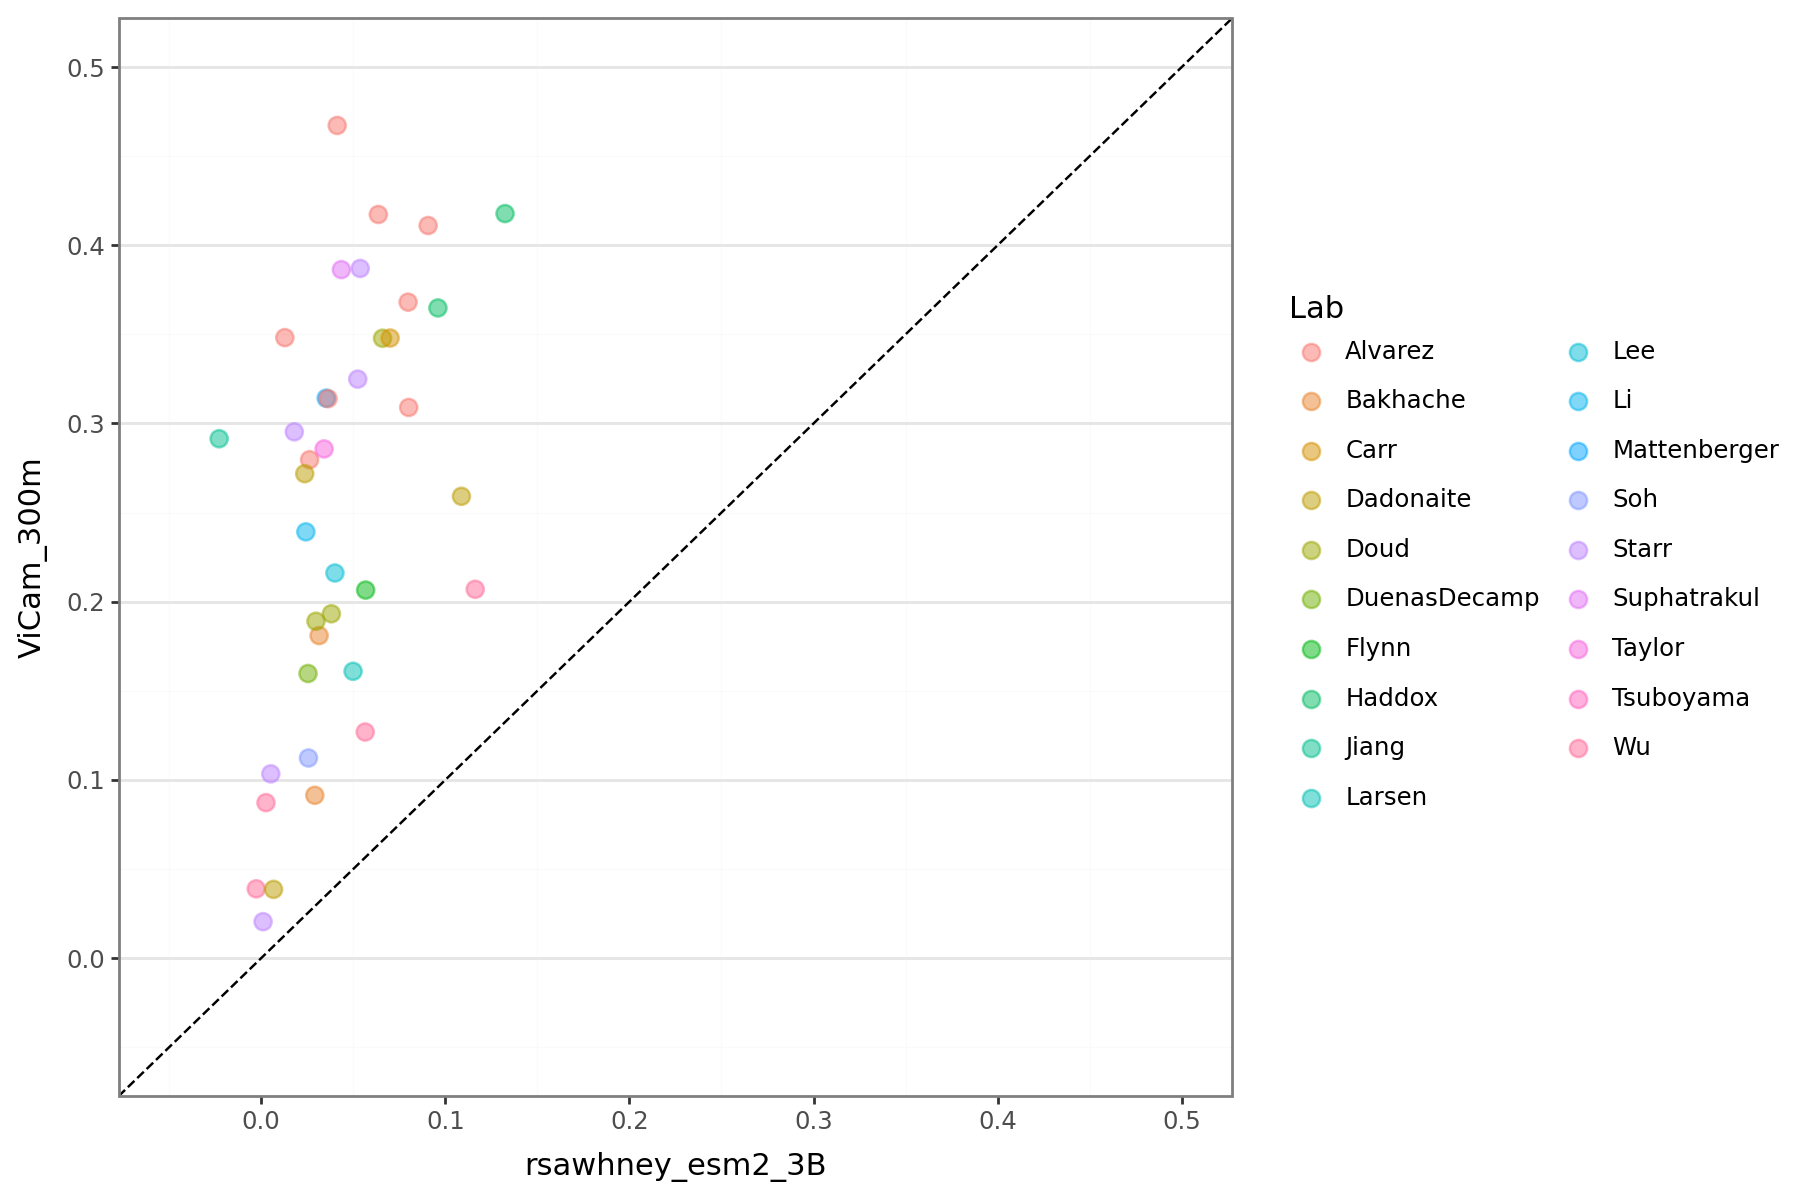

In [16]:
plot = (
    pln.ggplot(res_pivot, pln.aes(x='rsawhney_esm2_3B', y='ViCam_300m'))
    + pln.geom_point(pln.aes(color='Lab'), size=3, alpha=0.5)
    + pln.geom_abline(intercept=0, slope=1, linetype='dashed', color='black')  # 1:1 line
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
        figure_size=(9, 6),
    )
    + pln.labs(
        y='ViCam_300m',
        x='rsawhney_esm2_3B',
    )
    + pln.ylim(-0.05, .5)
    + pln.xlim(-0.05, .5)
)

plot#.save(filename='../experiments/res_vicam_x_rsawhney.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


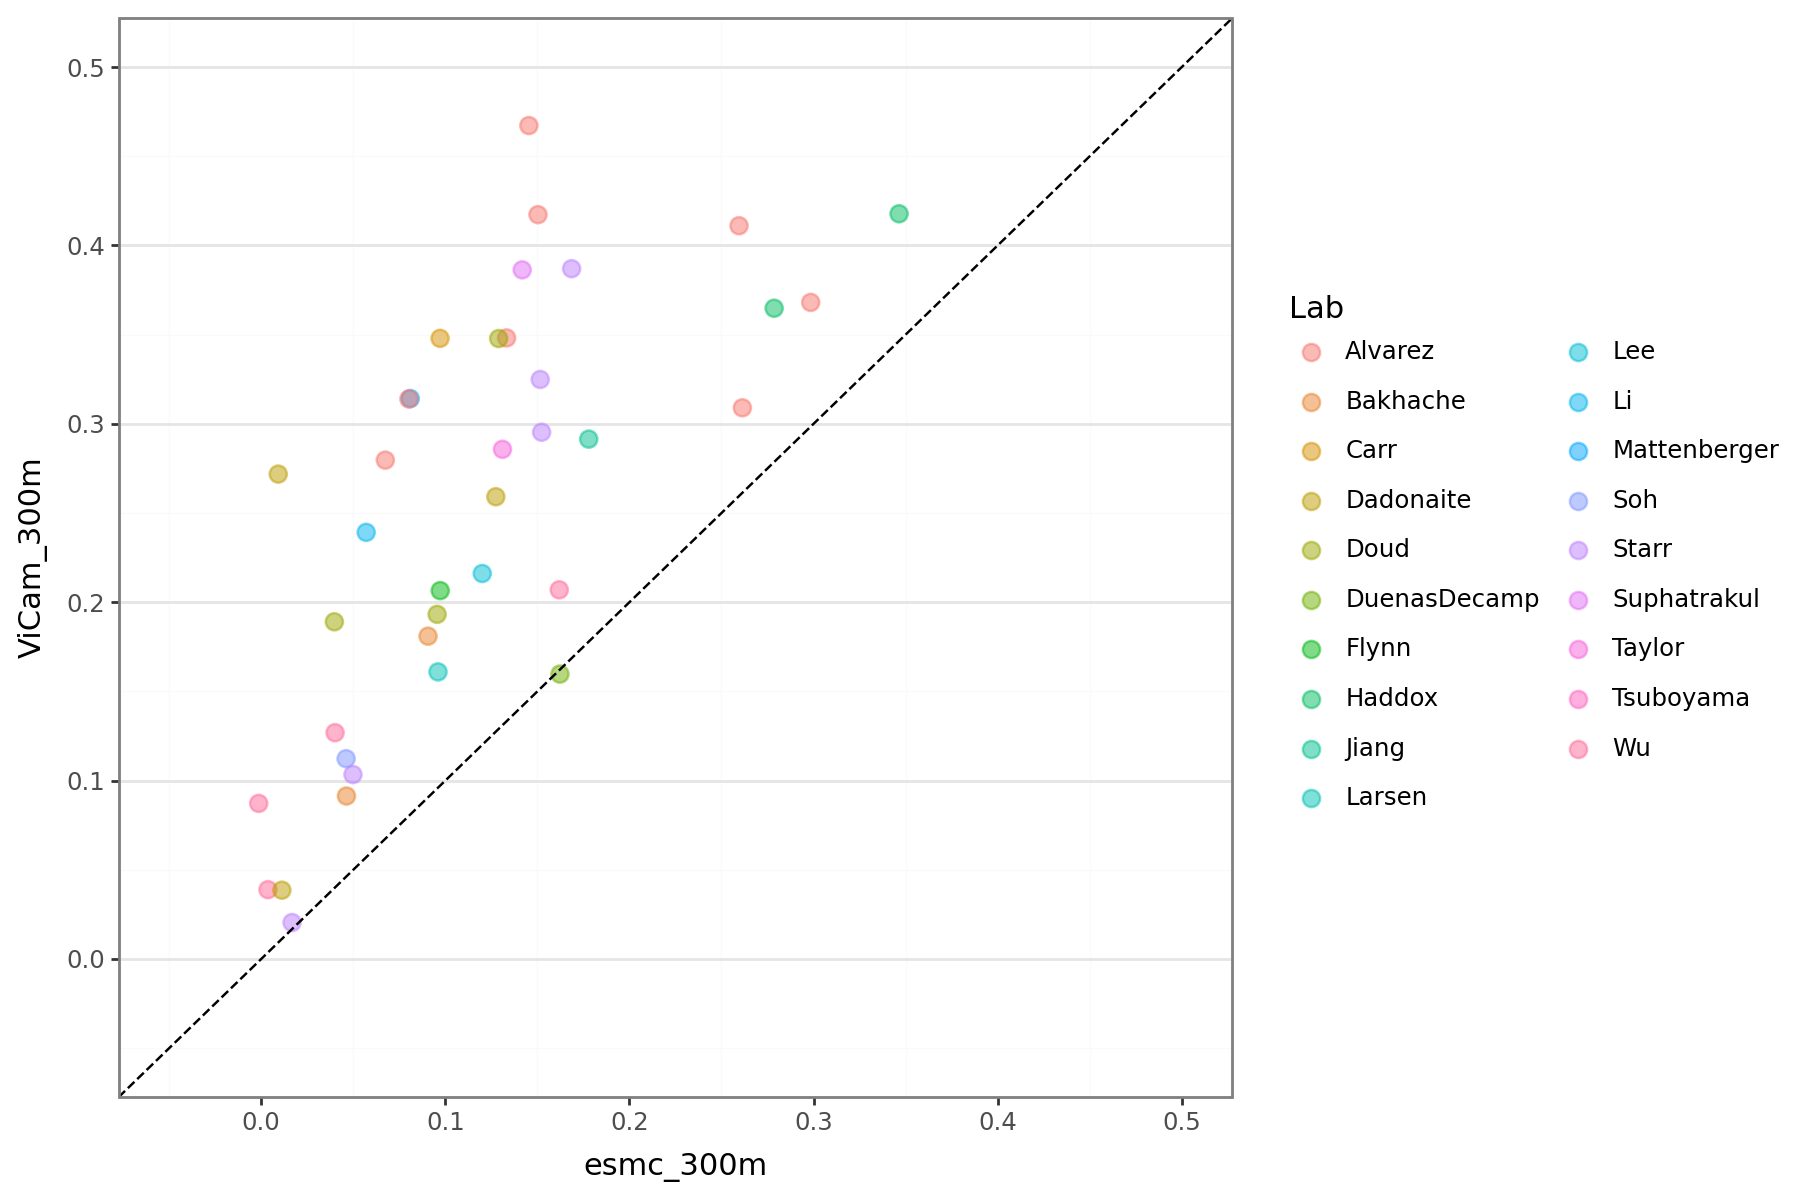

In [17]:
plot = (
    pln.ggplot(res_pivot, pln.aes(x='esmc_300m', y='ViCam_300m'))
    + pln.geom_point(pln.aes(color='Lab'), size=3, alpha=0.5)
    + pln.geom_abline(intercept=0, slope=1, linetype='dashed', color='black')  # 1:1 line
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
        figure_size=(9, 6),
    )
    + pln.labs(
        y='ViCam_300m',
        x='esmc_300m',
    )
    + pln.ylim(-0.05, .5)
    + pln.xlim(-0.05, .5)
)

plot#.save(filename='../experiments/res_vicam_x_esmc_300m.png', dpi=600)

In [17]:
# res_full = res_full[~res_full['dataset'].str.contains('Wu2016|Dodonaite2024')].copy()
# res_full

In [18]:
res_full['Model'] = pd.Categorical(res_full['Model'], 
                                    categories=['ViCam_300m', 'esmc_300m', 'rsawhney_esm2_3B'])
                                    #categories=['ViCam_300m', 'esmc_300m'])

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 13 rows containing non-finite values.


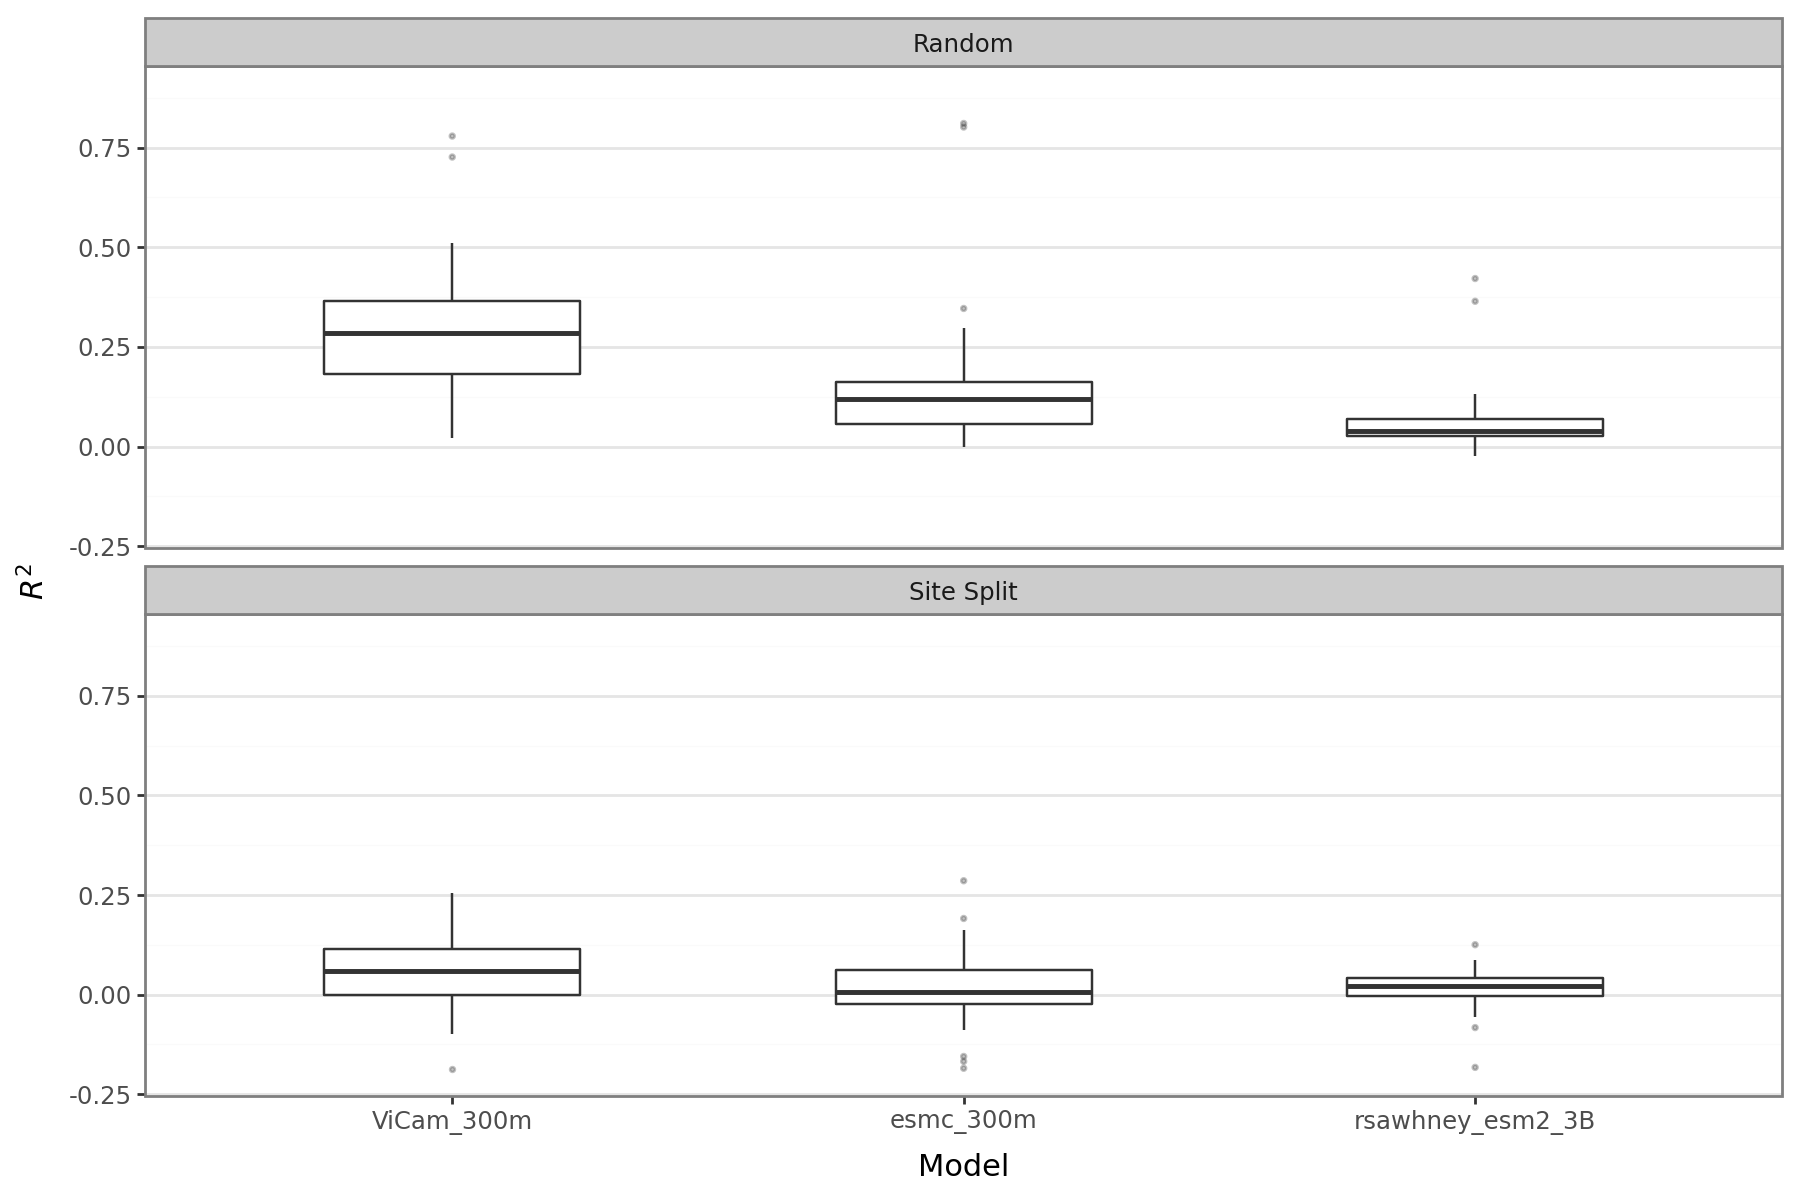

In [19]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
        figure_size=(9, 6),
    )
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.ylim(-0.2, .9)
    + pln.facet_wrap('split_method', nrow=2, scales='free_y')
)


plot#.save(filename='../experiments/res_finetuned_models_r2.png', dpi=600)

In [27]:
# plot = (
#     pln.ggplot(res_full, pln.aes(x='Model', y='rho_score_test'))
#     + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
#     + pln.theme_bw()
#     + pln.theme(
#         figure_size=(9, 6),
#         panel_grid_major_x=pln.element_blank(),
#     )
#     + pln.labs(
#         x='Model',
#         y='|Spearman ρ|',
#     )
#     + pln.facet_wrap('split_method', nrow=2, scales='free_y')
# )

# plot#.save(filename='../experiments/res_finetuned_models_rho.png', dpi=600)

In [1]:
import os
import pandas as pd

import torch


ImportError: libffi.so.7: cannot open shared object file: No such file or directory